# Fase 3 — Análise (Camada Gold)

Este notebook responde as perguntas de negócio do desafio, primeiro consultando
direto a camada **Silver**, depois construindo uma camada **Gold** agregada
(tabela e view) e usando ela para as demais perguntas.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from banco import conectar

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def consultar(sql, params=None):
    """Roda uma query e devolve um DataFrame do pandas."""
    conexao = conectar()
    try:
        return pd.read_sql(sql, conexao, params=params)
    finally:
        conexao.close()

## Parte A — 3 perguntas direto na camada Silver

### 1. Qual a viagem de maior duração e qual foi o seu custo total?

Consulta direta em `silver_viagem` (já tem `duracao_dias` e `valor_total`
calculados na Fase 2 — não precisa de JOIN).

In [2]:
sql_maior_duracao = """
    SELECT id_viagem, nome_orgao_superior, nome_viajante,
           data_inicio, data_fim, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC
    LIMIT 10;
"""
df_duracao = consultar(sql_maior_duracao)
df_duracao

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,id_viagem,nome_orgao_superior,nome_viajante,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,LUISANGELA CORREA FRANCO DE FARIA,2025-01-13,2026-01-31,383,0.00
1,0000000000020793594,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-02,2026-01-15,378,"120,650.00"
2,0000000000020774569,Ministério da Educação,CLAUDIA ADRIANA DA SILVA,2025-02-26,2026-03-02,369,0.00
3,0000000000020793492,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-11,2026-01-15,369,"113,382.50"
4,0000000000020685666,Ministério da Justiça e Segurança Pública,STEFANO DOS SANTOS NUNES,2025-01-01,2026-01-02,366,"124,312.50"
5,0000000000020592696,Ministério da Justiça e Segurança Pública,RAILANA BERENICE AMORAS OLIVEIRA,2025-01-01,2026-01-02,366,"159,044.90"
6,0000000000020589962,Ministério da Educação,BRUNO WANDERLEY FRANCA,2025-02-23,2026-02-23,365,0.00
7,0000000000020732132,Ministério da Educação,GILBERTO SANTOS ANDRADE,2025-03-31,2026-03-31,365,0.00
8,0000000000020545713,Ministério da Justiça e Segurança Pública,FRANCISCO COSTA DA SILVA JUNIOR,2025-01-01,2025-12-31,364,"128,357.50"
9,0000000000020805749,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-01,2025-12-31,364,"97,847.50"


Viagem mais longa: 0000000000020699856 (Ministério da Previdência Social) — 383 dias, custo total de R$ 0.00


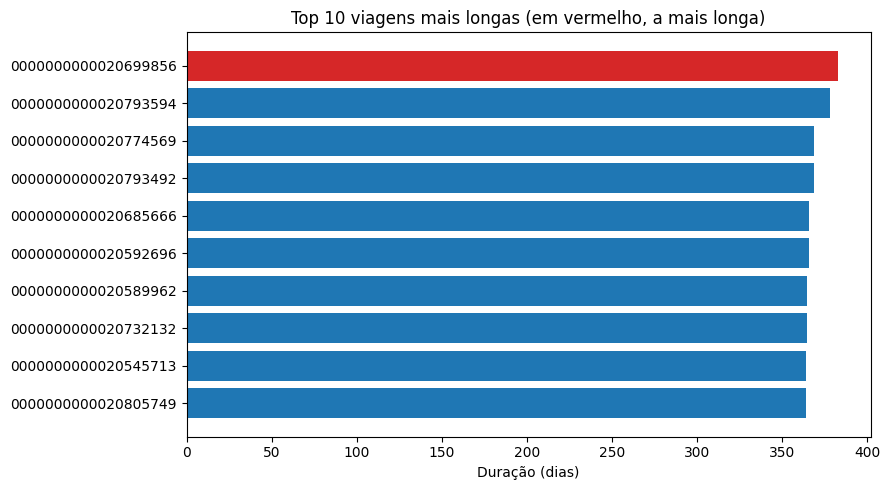

In [3]:
viagem_mais_longa = df_duracao.iloc[0]
print(
    f"Viagem mais longa: {viagem_mais_longa['id_viagem']} "
    f"({viagem_mais_longa['nome_orgao_superior']}) — "
    f"{viagem_mais_longa['duracao_dias']} dias, "
    f"custo total de R$ {viagem_mais_longa['valor_total']:,.2f}"
)

fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#d62728" if i == 0 else "#1f77b4" for i in range(len(df_duracao))]
ax.barh(df_duracao["id_viagem"].astype(str), df_duracao["duracao_dias"], color=cores)
ax.invert_yaxis()
ax.set_xlabel("Duração (dias)")
ax.set_title("Top 10 viagens mais longas (em vermelho, a mais longa)")
plt.tight_layout()
plt.show()

### 2. Qual o tipo de pagamento com maior valor médio?

Consulta direta em `silver_pagamento` (`GROUP BY tipo_pagamento`).

In [4]:
sql_tipo_pagamento = """
    SELECT tipo_pagamento, COUNT(*) AS qtd, AVG(valor) AS valor_medio
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC;
"""
df_tipo_pagamento = consultar(sql_tipo_pagamento)
df_tipo_pagamento

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,tipo_pagamento,qtd,valor_medio
0,DIÁRIAS,401463,"2,078.28"
1,PASSAGEM,188985,"1,878.34"
2,Serviço correlato: seguro,4894,447.51
3,RESTITUIÇÃO,11574,245.70


Tipo de pagamento com maior valor médio: DIÁRIAS (R$ 2,078.28 em média, 401463 pagamentos)


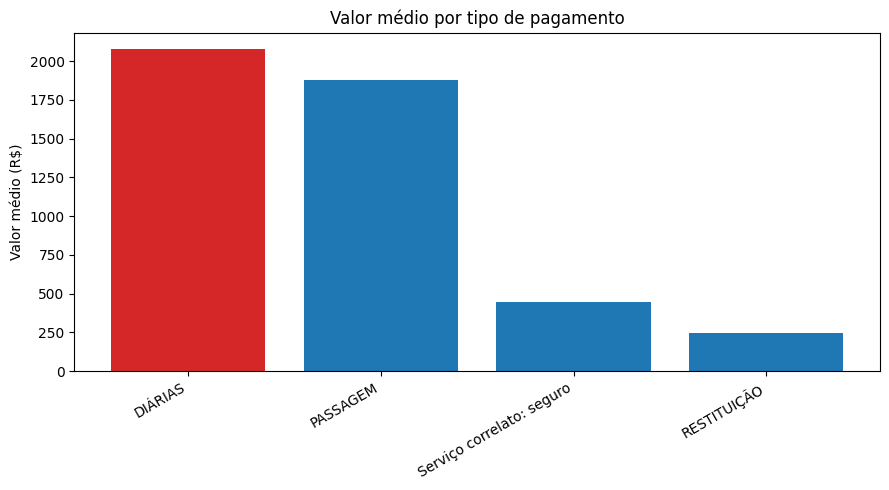

In [5]:
top_tipo = df_tipo_pagamento.iloc[0]
print(
    f"Tipo de pagamento com maior valor médio: {top_tipo['tipo_pagamento']} "
    f"(R$ {top_tipo['valor_medio']:,.2f} em média, {top_tipo['qtd']} pagamentos)"
)

fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#d62728" if i == 0 else "#1f77b4" for i in range(len(df_tipo_pagamento))]
ax.bar(df_tipo_pagamento["tipo_pagamento"], df_tipo_pagamento["valor_medio"], color=cores)
ax.set_ylabel("Valor médio (R$)")
ax.set_title("Valor médio por tipo de pagamento")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3. Qual o meio de transporte mais usado nos trechos?

Consulta direta em `silver_trecho` (`GROUP BY meio_transporte`).

In [6]:
sql_transporte = """
    SELECT meio_transporte, COUNT(*) AS qtd
    FROM silver_trecho
    GROUP BY meio_transporte
    ORDER BY qtd DESC;
"""
df_transporte = consultar(sql_transporte)
df_transporte

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,meio_transporte,qtd
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


Meio de transporte mais usado: Veículo Oficial (386424 trechos)


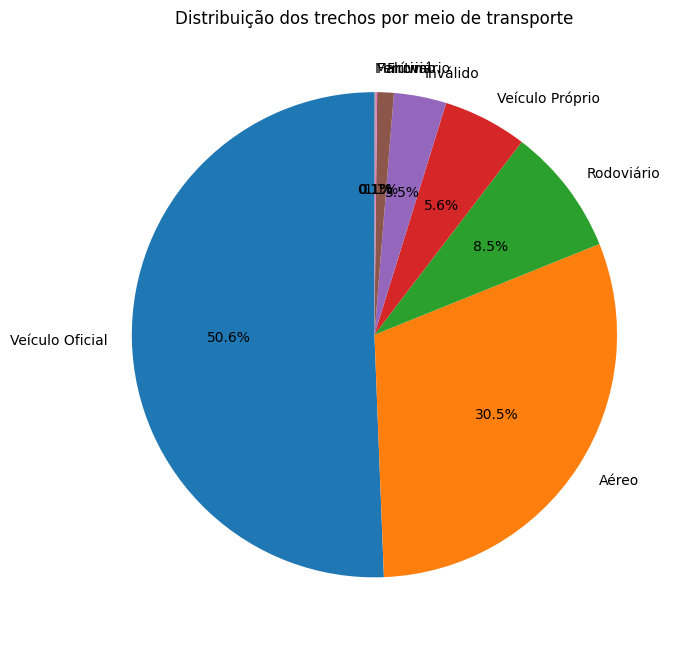

In [7]:
top_transporte = df_transporte.iloc[0]
print(
    f"Meio de transporte mais usado: {top_transporte['meio_transporte']} "
    f"({top_transporte['qtd']} trechos)"
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    df_transporte["qtd"],
    labels=df_transporte["meio_transporte"],
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title("Distribuição dos trechos por meio de transporte")
plt.tight_layout()
plt.show()

## Camada Gold — `gold_orgao_destino`

Agrega `silver_viagem` + `silver_trecho` por **(órgão, UF de destino)**.

**Cuidado de modelagem:** uma viagem pode ter vários trechos (destinos). Se
simplesmente somássemos `valor_total` depois de um JOIN direto com
`silver_trecho`, o custo de uma viagem com 3 destinos seria contado 3 vezes
(inflando o resultado — chegamos a medir uma inflação de ~5x nos testes).
Por isso, a query abaixo calcula o custo total por órgão **antes** do JOIN
(numa sub-consulta separada, sem duplicar) e só usa o JOIN com trechos para
contar trechos e destinos — que é exatamente o que ele deve fazer.

In [8]:
sql_criar_gold = """
    DROP TABLE IF EXISTS gold_orgao_destino;

    CREATE TABLE gold_orgao_destino AS
    WITH custo_por_orgao AS (
        SELECT
            nome_orgao_superior AS orgao,
            COUNT(*) AS qtd_viagens_orgao,
            SUM(valor_total) AS custo_total_orgao
        FROM silver_viagem
        GROUP BY nome_orgao_superior
    ),
    trechos_por_orgao_uf AS (
        SELECT
            v.nome_orgao_superior AS orgao,
            t.destino_uf,
            COUNT(*) AS qtd_trechos,
            COUNT(DISTINCT v.id_viagem) AS qtd_viagens_destino
        FROM silver_viagem v
        JOIN silver_trecho t ON t.id_viagem = v.id_viagem
        WHERE t.destino_uf IS NOT NULL AND TRIM(t.destino_uf) <> ''
        GROUP BY v.nome_orgao_superior, t.destino_uf
    )
    SELECT
        tpo.orgao,
        tpo.destino_uf,
        tpo.qtd_trechos,
        tpo.qtd_viagens_destino,
        cpo.qtd_viagens_orgao,
        cpo.custo_total_orgao
    FROM trechos_por_orgao_uf tpo
    JOIN custo_por_orgao cpo ON cpo.orgao = tpo.orgao;
"""

sql_criar_view = """
    CREATE OR REPLACE VIEW gold_orgao_destino_view AS
    WITH custo_por_orgao AS (
        SELECT
            nome_orgao_superior AS orgao,
            COUNT(*) AS qtd_viagens_orgao,
            SUM(valor_total) AS custo_total_orgao
        FROM silver_viagem
        GROUP BY nome_orgao_superior
    ),
    trechos_por_orgao_uf AS (
        SELECT
            v.nome_orgao_superior AS orgao,
            t.destino_uf,
            COUNT(*) AS qtd_trechos,
            COUNT(DISTINCT v.id_viagem) AS qtd_viagens_destino
        FROM silver_viagem v
        JOIN silver_trecho t ON t.id_viagem = v.id_viagem
        WHERE t.destino_uf IS NOT NULL AND TRIM(t.destino_uf) <> ''
        GROUP BY v.nome_orgao_superior, t.destino_uf
    )
    SELECT
        tpo.orgao,
        tpo.destino_uf,
        tpo.qtd_trechos,
        tpo.qtd_viagens_destino,
        cpo.qtd_viagens_orgao,
        cpo.custo_total_orgao
    FROM trechos_por_orgao_uf tpo
    JOIN custo_por_orgao cpo ON cpo.orgao = tpo.orgao;
"""

conexao = conectar()
try:
    cursor = conexao.cursor()
    cursor.execute(sql_criar_gold)
    cursor.execute(sql_criar_view)
    conexao.commit()
    cursor.close()
    print("[OK] Tabela 'gold_orgao_destino' e view 'gold_orgao_destino_view' criadas.")
finally:
    conexao.close()

[OK] Tabela 'gold_orgao_destino' e view 'gold_orgao_destino_view' criadas.


In [9]:
df_gold_tabela = consultar("SELECT * FROM gold_orgao_destino ORDER BY orgao, destino_uf;")
df_gold_view = consultar("SELECT * FROM gold_orgao_destino_view ORDER BY orgao, destino_uf;")

print("Linhas na tabela:", len(df_gold_tabela))
print("Linhas na view:", len(df_gold_view))
print("Tabela e view batem?", df_gold_tabela.equals(df_gold_view))
df_gold_tabela.head()

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


Linhas na tabela: 909
Linhas na view: 909
Tabela e view batem? True


,orgao,destino_uf,qtd_trechos,qtd_viagens_destino,qtd_viagens_orgao,custo_total_orgao
0,Advocacia-Geral da União,Acre,28,15,1334,"4,194,876.48"
1,Advocacia-Geral da União,Alagoas,14,14,1334,"4,194,876.48"
2,Advocacia-Geral da União,Amapá,2,2,1334,"4,194,876.48"
3,Advocacia-Geral da União,Amazonas,36,33,1334,"4,194,876.48"
4,Advocacia-Geral da União,Bahia,86,84,1334,"4,194,876.48"


## Parte B — 4 perguntas usando a camada Gold

### 4. Quais os 5 órgãos com maior custo total?

O `custo_total_orgao` já vem correto (sem duplicar) da Gold — usamos
`DISTINCT` porque esse valor se repete em cada linha (uma por UF) do mesmo
órgão.

In [10]:
sql_top_orgaos = """
    SELECT DISTINCT orgao, custo_total_orgao
    FROM gold_orgao_destino
    ORDER BY custo_total_orgao DESC
    LIMIT 5;
"""
df_top_orgaos = consultar(sql_top_orgaos)
df_top_orgaos

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,orgao,custo_total_orgao
0,Ministério da Justiça e Segurança Pública,"490,813,474.85"
1,Ministério da Defesa,"157,059,698.59"
2,Ministério da Educação,"112,519,456.96"
3,Ministério do Meio Ambiente e Mudança do Clima,"50,548,377.44"
4,Ministério da Previdência Social,"40,921,476.10"


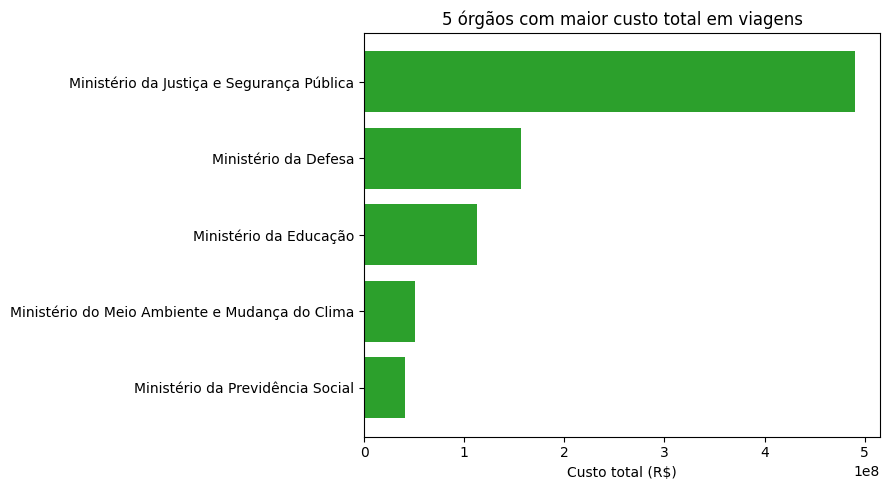

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_top_orgaos["orgao"], df_top_orgaos["custo_total_orgao"], color="#2ca02c")
ax.invert_yaxis()
ax.set_xlabel("Custo total (R$)")
ax.set_title("5 órgãos com maior custo total em viagens")
plt.tight_layout()
plt.show()

### 5. Quais os 3 destinos (UF) com maior custo médio por viagem?

Aqui usamos as tabelas Silver diretamente (com `DISTINCT` em
`id_viagem, destino_uf` pra não contar duas vezes uma viagem que teve mais de
um trecho para o mesmo estado) — é uma métrica de **média**, diferente da
soma que está pré-calculada na Gold.

In [12]:
sql_custo_medio_destino = """
    SELECT destino_uf, AVG(valor_total) AS custo_medio, COUNT(*) AS qtd_viagens
    FROM (
        SELECT DISTINCT v.id_viagem, t.destino_uf, v.valor_total
        FROM silver_viagem v
        JOIN silver_trecho t ON t.id_viagem = v.id_viagem
        WHERE t.destino_uf IS NOT NULL AND TRIM(t.destino_uf) <> ''
    ) AS viagem_destino
    GROUP BY destino_uf
    ORDER BY custo_medio DESC
    LIMIT 3;
"""
df_custo_medio_destino = consultar(sql_custo_medio_destino)
df_custo_medio_destino

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,destino_uf,custo_medio,qtd_viagens
0,Roraima,"11,277.48",8850
1,Acre,"8,378.20",5399
2,Rondônia,"8,252.80",7838


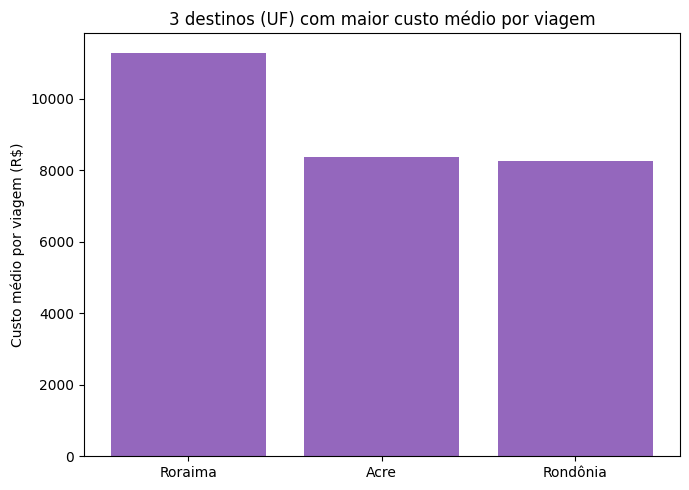

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(df_custo_medio_destino["destino_uf"], df_custo_medio_destino["custo_medio"], color="#9467bd")
ax.set_ylabel("Custo médio por viagem (R$)")
ax.set_title("3 destinos (UF) com maior custo médio por viagem")
plt.tight_layout()
plt.show()

### 6. Qual UF de destino aparece em mais trechos?

Usa a `qtd_trechos` já calculada na Gold — aqui somar é seguro, porque
`qtd_trechos` já é uma contagem de linhas (não um valor monetário que possa
ser duplicado).

In [14]:
sql_uf_mais_trechos = """
    SELECT destino_uf, SUM(qtd_trechos) AS total_trechos
    FROM gold_orgao_destino
    GROUP BY destino_uf
    ORDER BY total_trechos DESC
    LIMIT 10;
"""
df_uf_trechos = consultar(sql_uf_mais_trechos)
df_uf_trechos

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,destino_uf,total_trechos
0,São Paulo,"82,722.00"
1,Distrito Federal,"79,962.00"
2,Minas Gerais,"50,965.00"
3,Rio de Janeiro,"44,197.00"
4,Paraná,"42,603.00"
5,Pará,"40,044.00"
6,Rio Grande do Sul,"38,684.00"
7,Mato Grosso do Sul,"30,516.00"
8,Bahia,"28,375.00"
9,Pernambuco,"28,372.00"


UF de destino que mais aparece em trechos: São Paulo (82722.0 trechos)


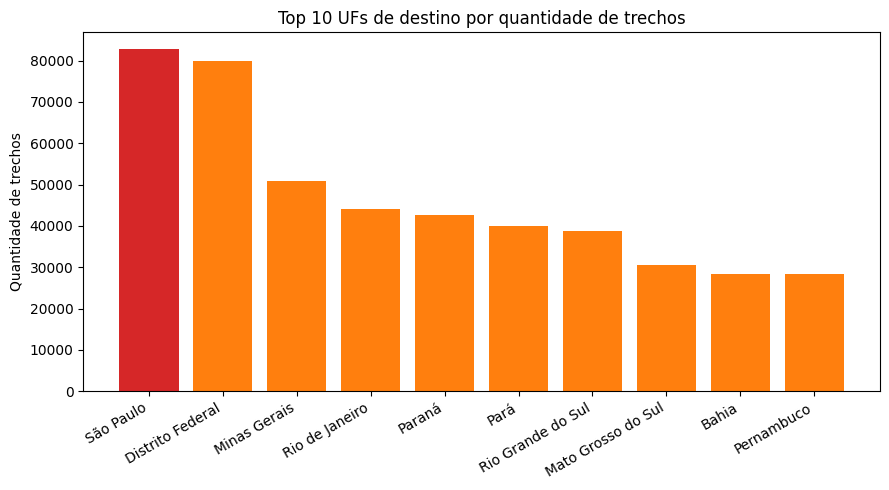

In [15]:
top_uf = df_uf_trechos.iloc[0]
print(f"UF de destino que mais aparece em trechos: {top_uf['destino_uf']} ({top_uf['total_trechos']} trechos)")

fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#d62728" if i == 0 else "#ff7f0e" for i in range(len(df_uf_trechos))]
ax.bar(df_uf_trechos["destino_uf"], df_uf_trechos["total_trechos"], color=cores)
ax.set_ylabel("Quantidade de trechos")
ax.set_title("Top 10 UFs de destino por quantidade de trechos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 7. Qual órgão pagou mais no total?

Atenção: essa pergunta é sobre o **órgão pagador** (`nome_orgao_pagador`, em
`silver_pagamento`) — que pode ser diferente do órgão do viajante
(`nome_orgao_superior`, usado na pergunta 4). Um viajante pode ser vinculado
a um órgão mas ter a viagem paga por outro (ex: convênio, fundo específico).
Por isso é uma métrica separada, direto na Silver.

In [16]:
sql_top_pagador = """
    SELECT nome_orgao_pagador, SUM(valor) AS total_pago
    FROM silver_pagamento
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
    LIMIT 5;
"""
df_top_pagador = consultar(sql_top_pagador)
df_top_pagador

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15820\2172677694.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao, params=params)


,nome_orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,"278,481,047.89"
1,Sigiloso,"200,484,801.68"
2,Comando da Aeronáutica,"81,769,144.77"
3,Instituto Nacional do Seguro Social,"37,427,601.45"
4,Comando do Exército,"36,872,643.95"


Órgão que mais pagou no total: Fundo Nacional de Segurança Pública (R$ 278,481,047.89)


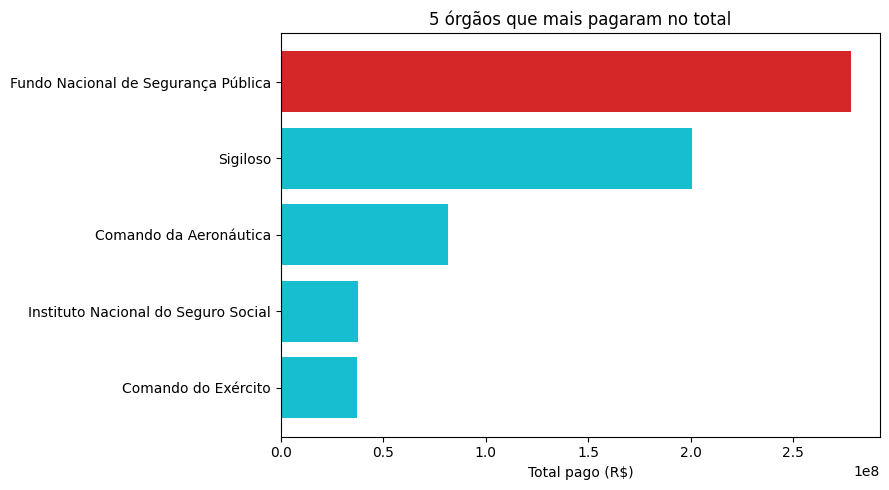

In [17]:
top_pagador = df_top_pagador.iloc[0]
print(f"Órgão que mais pagou no total: {top_pagador['nome_orgao_pagador']} (R$ {top_pagador['total_pago']:,.2f})")

fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#d62728" if i == 0 else "#17becf" for i in range(len(df_top_pagador))]
ax.barh(df_top_pagador["nome_orgao_pagador"], df_top_pagador["total_pago"], color=cores)
ax.invert_yaxis()
ax.set_xlabel("Total pago (R$)")
ax.set_title("5 órgãos que mais pagaram no total")
plt.tight_layout()
plt.show()

## Conclusões

*(preencher depois de rodar tudo e olhar os resultados/gráficos — o
documento pede uma seção de conclusões e insights no README, e vale
resumir aqui também)*
